In [ ]:
from matplotlib import pyplot as plt
from tqdm import tqdm
import itertools
import os
import numpy as np
import scipy.sparse
import pandas as pd
import re
import importlib.util
import sys
import scanpy as sc
import seaborn as sns
import random

In [ ]:
import matplotlib
from matplotlib.gridspec import GridSpec
from datetime import datetime
from matplotlib.ticker import FixedLocator, FixedFormatter
from tqdm import tqdm
matplotlib.rcParams["text.usetex"] = False
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
from matplotlib import rc
rc('font',**{'family':'sans-serif','sans-serif':['Arial']})

sc.set_figure_params(dpi=80)
plt.rcParams['axes.grid'] = False


In [ ]:
import importlib.util
import sys

def lazy_import(module_name, path_to_file):
    spec = importlib.util.spec_from_file_location(module_name,path_to_file)
    foo = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = foo
    spec.loader.exec_module(foo)
    return foo

utils_dir = "../../utils"
general_utils =  lazy_import("general_utils",os.path.join(utils_dir, "general_utils.py"))
anndata_utils = lazy_import("anndata_utils",os.path.join(utils_dir, "anndata_utils.py"))
neighborhood_utils = lazy_import("neighborhood_utils",os.path.join(utils_dir, "neighborhood_utils.py"))

from general_utils import ismember, grep, grep_exclude, read_object, write_object
from plotting_functions import get_custom_legend_patches, get_custom_legend_circles
from neighborhood_utils import create_diagonal_matrix, get_average_neighborhood_expression, get_neighborhood_fraction, get_neighborhood_count, compute_distances_within_neighborhood


### Import dataset

In [ ]:
adata_all = sc.read_h5ad("../data/Reyes_Xenium_TIER_all_SUBSET_all__annotated.h5ad")
adata_neighborhood = sc.read_h5ad("../data/Reyes_Xenium_TIER_all_SUBSET_all__spatial_neighborhood.h5ad")
adata_DC = sc.read_h5ad('../data/Reyes_Xenium_TIER_tier3_SUBSET_Premalignant0.h5ad')


### Import diffusion maps results

In [ ]:
# Bin diffusion component and transfer all DC values into adata_epi object
diff_comp = adata_DC.obs["progenitor_DC"].to_numpy()

n_bins = 100
breaks = np.quantile(diff_comp, np.linspace(start=0, stop=1, num=n_bins+1))
progenitor_DC_digitized = np.digitize(diff_comp, breaks)

progenitor_DC = np.array([np.nan] * adata_all.n_obs, dtype = np.float32)
progenitor_DC[np.where(ismember(adata_all.obs_names, adata_DC.obs_names)[1])[0]] = diff_comp
adata_all.obs['progenitor_DC_original'] = progenitor_DC.copy()

progenitor_DC = np.array([np.nan] * adata_all.n_obs)
progenitor_DC[np.where(ismember(adata_all.obs_names, adata_DC.obs_names)[1])[0]] = progenitor_DC_digitized
adata_all.obs['progenitor_DC_binned'] = progenitor_DC.copy()

### Bin epithelial neighborhoods on the basis of average DC

In [ ]:
selected_radius = 60
spatial_neighborhood = adata_neighborhood.obsp['spatial_neighborhood']

# Subset valid epithelial
valid_epithelial = np.logical_not(np.isnan(adata_all.obs['progenitor_DC_binned'].to_numpy()))
spatial_neighborhood_sub = spatial_neighborhood[:,valid_epithelial].copy()
progenitor_DC_array = adata_all.obs['progenitor_DC_original'][valid_epithelial].to_numpy()[:,None]

# Compute average progenitor DC
sum_progenitor_DC = np.ravel(spatial_neighborhood_sub @ progenitor_DC_array)
count_progenitor_DC = np.ravel(spatial_neighborhood_sub.sum(axis=1))
mean_progenitor_DC = sum_progenitor_DC / count_progenitor_DC

# Get into data frame
adata_all.obs['progenitor_neighborhood_score'] = mean_progenitor_DC.copy()
adata_all.obs['count_valid_epithelial'] = count_progenitor_DC.copy()
#selected_columns = ['progenitor_DC_original', 'progenitor_DC_binned', 'progenitor_neighborhood_score', 'count_valid_epithelial']
#df = adata_all.obs[selected_columns]


/data/lowe/reyesj3/repositories/temp/ipykernel_91636/1068835470.py:12: RuntimeWarning: invalid value encountered in divide
  mean_progenitor_DC = sum_progenitor_DC / count_progenitor_DC


In [ ]:
df

,progenitor_DC_original,progenitor_DC_binned,progenitor_neighborhood_score,count_valid_epithelial
0004279_Region_1__aaaadbim-1,NaN,NaN,-0.000198,15
0004279_Region_1__aaaakfhd-1,-0.000151,66.0,-0.000053,6
0004279_Region_1__aaabfjfa-1,NaN,NaN,-0.000218,13
0004279_Region_1__aaabgcen-1,NaN,NaN,-0.000196,16
0004279_Region_1__aaabhmka-1,NaN,NaN,-0.000229,10
...,...,...,...,...
0042724_Region_3__oikobdbn-1,NaN,NaN,NaN,0
0042724_Region_3__oikobfhl-1,NaN,NaN,NaN,0
0042724_Region_3__oikolbea-1,NaN,NaN,NaN,0
0042724_Region_3__oikophhp-1,NaN,NaN,NaN,0


### Bin cells based on a specific observation

In [ ]:
n_bins = 100

obs_to_bin = 'progenitor_neighborhood_score'

# Filter cells to exclude neighborhoods with few epithelial cells that may introduce noise
valid_obs = np.logical_not(np.isnan(adata_all.obs[obs_to_bin]))
valid_obs = np.logical_and(valid_obs, adata_all.obs['count_valid_epithelial'] > 10)

# Bin by quantiles
breaks = np.quantile(adata_all.obs[obs_to_bin][valid_obs], np.linspace(start=0, stop=1, num=n_bins+1))
obs_digitized = np.digitize(adata_all.obs[obs_to_bin], breaks)

obs_axis = np.array([np.nan] * adata_all.n_obs)
obs_axis[valid_obs] = obs_digitized[valid_obs]
adata_all.obs['binned_obs'] = obs_axis.copy()


### Import neighborhood counts

In [ ]:
df = pd.read_csv(os.path.join("../cell_type_counts/", "celltype_counts_RADIUS_" + str(selected_radius) + ".csv.gz"), index_col = 0)

In [ ]:
df['count_valid_epithelial'] = adata_all.obs['count_valid_epithelial'].to_numpy()
df['total_neighbors'] = np.ravel(spatial_neighborhood.sum(axis=1))
df['fraction_epi'] = df['count_OBS_cell_type_0_CAT_Epithelial'] / df['total_neighbors']
df['fraction_valid_epi'] = df['count_valid_epithelial'] / df['count_OBS_cell_type_0_CAT_Epithelial']
df['binned_obs'] = adata_all.obs['binned_obs']

Filter adata to include only certain conditions

In [ ]:
selected_conditions = ['K2_vehicle', 'K2_ctrl', 'K2d1_ctrl', 'K3_ctrl']
condition_filter = ismember(adata_all.obs['condition'], selected_conditions)[1]
adata_sub = adata_all[condition_filter,:].copy()

### Compute cell fractions as a function of DC

In [ ]:
merged_types = {
    'count_OBS_cell_type_1_CAT_gastric_all': ['gastric', 'gastric_pit', 'gastric_chief', 'gastric_Ccn2'],
    'count_OBS_cell_type_1_CAT_progenitor_all': ['progenitor1', 'progenitor2'],
    'count_OBS_cell_type_1_CAT_TAM_Itgax': ['TAM_Itgax_1', 'TAM_Cd274'],
}

possible_coarse_types = ['Epithelial', 'Immune_Myeloid', 'Fibroblast', 'Immune_TNKILC']
result_type_counts = []
result_normalization_counts = []

min_coarse_count = 10
min_valid_epithelial = 10

for selected_cell_type_coarse in tqdm(possible_coarse_types):
    # Identify possible refined cell types
    selected_cell_type_refined = np.unique(adata_all.obs['cell_type_1'][adata_all.obs['cell_type_0'] == selected_cell_type_coarse])
    normalization_column = 'count_OBS_cell_type_0_CAT_' + selected_cell_type_coarse
    selected_columns = ['count_OBS_cell_type_1_CAT_' + x for x in selected_cell_type_refined]

    # Format normalization vector to include nan in invalid niches
    df_current = df.loc[adata_sub.obs_names, selected_columns].copy()
    normalization_vector = df.loc[adata_sub.obs_names, normalization_column].to_numpy().astype(np.float32)
    valid_cells = np.logical_and(adata_sub.obs['count_valid_epithelial'] > min_valid_epithelial, normalization_vector > min_coarse_count)
    normalization_vector[np.logical_not(valid_cells)] = np.nan
    display(np.sum(valid_cells))

    # Save data frames in list
    normalization_df = pd.concat([pd.Series(normalization_vector)] * len(selected_columns), axis = 1)
    normalization_df.columns = selected_columns
    result_type_counts.append(df_current)
    result_normalization_counts.append(normalization_df)
    
df_normalization = pd.concat(result_normalization_counts, axis = 1)
df_normalization.index = df_current.index
df_counts = pd.concat(result_type_counts, axis = 1)

  0%|          | 0/4 [00:00<?, ?it/s]

2771972

 25%|██▌       | 1/4 [00:08<00:26,  8.80s/it]

2047545

 50%|█████     | 2/4 [00:13<00:12,  6.28s/it]

2583376

 75%|███████▌  | 3/4 [00:18<00:05,  5.61s/it]

26024

100%|██████████| 4/4 [00:21<00:00,  5.39s/it]


In [ ]:
df_normalized = df_counts / df_normalization
df_normalized['binned_obs'] = adata_sub.obs['binned_obs']

In [ ]:
df_normalized.shape

(3958894, 44)

In [ ]:
# Add merged columns
for my_merged_type in merged_types.keys():
    temp_columns = ['count_OBS_cell_type_1_CAT_' + x for x in merged_types[my_merged_type]]
    if np.sum(ismember(temp_columns, df_normalized.columns)[1]) == len(temp_columns):
        df_temp = df_normalized.loc[:, temp_columns].copy()
        df_normalized[my_merged_type] = df_temp.sum(axis=1)

In [ ]:
summarized_median = df_normalized.groupby('binned_obs').agg(lambda x: np.nanquantile(x, 0.5)).iloc[:-1,:].copy()
summarized_25 = df_normalized.groupby('binned_obs').agg(lambda x: np.nanquantile(x, 0.25)).iloc[:-1,:].copy()
summarized_75 = df_normalized.groupby('binned_obs').agg(lambda x: np.nanquantile(x, 0.75)).iloc[:-1,:].copy()
summarized_count = df_normalized.groupby('binned_obs').agg(lambda x: np.sum(np.logical_not(np.isnan(x)))).iloc[:-1,:].copy()


/data/lowe/reyesj3/miniconda3/envs/rapidsai/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1559: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a,
/data/lowe/reyesj3/miniconda3/envs/rapidsai/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1559: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a,
/data/lowe/reyesj3/miniconda3/envs/rapidsai/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1559: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a,
/data/lowe/reyesj3/miniconda3/envs/rapidsai/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1559: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a,
/data/lowe/reyesj3/miniconda3/envs/rapidsai/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1559: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a,
/data/lowe/reyesj3/miniconda3/envs/rapidsai/lib/python3.9/site-packages/numpy/lib/nanfunctions.

In [ ]:
transition_point = summarized_median['count_OBS_cell_type_1_CAT_progenitor_all'] > summarized_median['count_OBS_cell_type_1_CAT_gastric_all']
transition_index = np.min(np.where(transition_point))

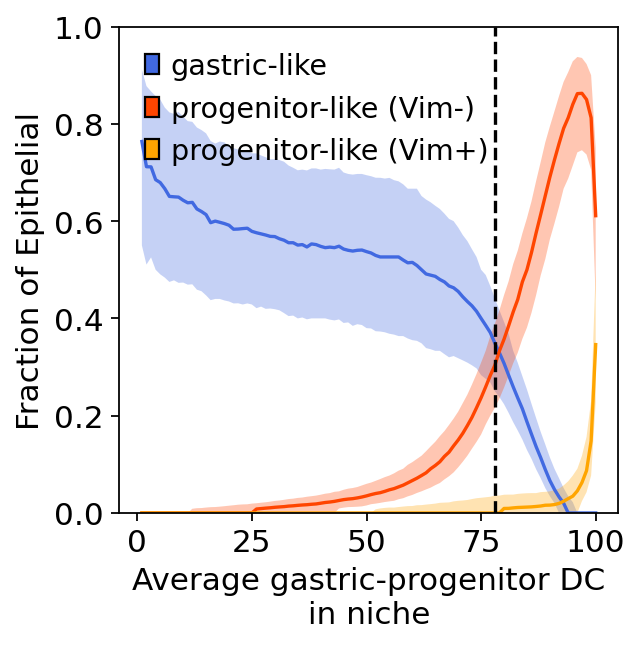

In [ ]:
selected_column = 'count_OBS_cell_type_1_CAT_gastric_all'
plt.plot(summarized_median.index, summarized_median[selected_column], 'royalblue')
plt.fill_between(summarized_median.index, summarized_25[selected_column], summarized_75[selected_column], alpha=0.3, color='royalblue', edgecolor='None', label='Confidence Interval')

selected_column = 'count_OBS_cell_type_1_CAT_progenitor1'
plt.plot(summarized_median.index, summarized_median[selected_column], 'orangered')
plt.fill_between(summarized_median.index, summarized_25[selected_column], summarized_75[selected_column], alpha=0.3, color='orangered', edgecolor='None', label='Confidence Interval')

selected_column = 'count_OBS_cell_type_1_CAT_progenitor2'
plt.plot(summarized_median.index, summarized_median[selected_column], 'orange')
plt.fill_between(summarized_median.index, summarized_25[selected_column], summarized_75[selected_column], alpha=0.3, color='orange', edgecolor='None', label='Confidence Interval')

plt.ylim([0,1])

patches = get_custom_legend_patches(['royalblue', 'orangered', 'orange'], ['gastric-like', 'progenitor-like (Vim-)', 'progenitor-like (Vim+)'])

plt.legend(handles = patches, frameon=False, loc='upper left')

plt.ylabel('Fraction of Epithelial')
plt.xlabel('Average gastric-progenitor DC\nin niche')

plt.plot([transition_index] * 2, plt.gca().get_ylim(), 'k--')


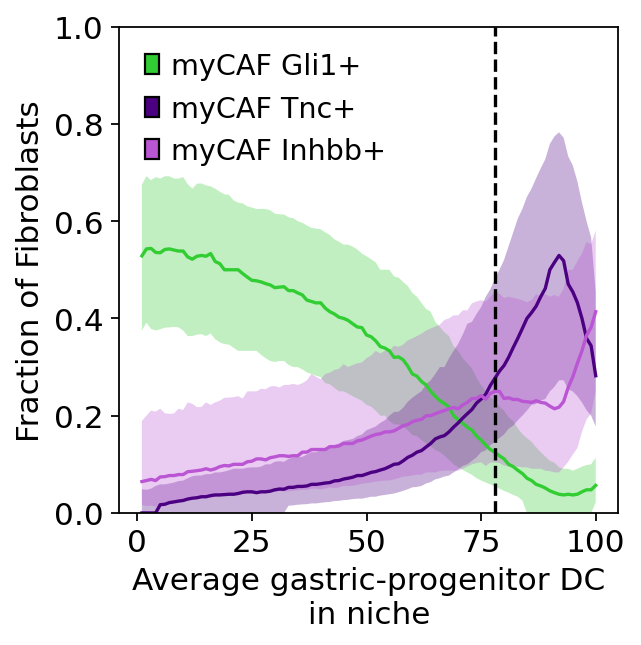

In [ ]:
selected_column = 'count_OBS_cell_type_1_CAT_myCAF_Gli1'
plt.plot(summarized_median.index, summarized_median[selected_column], 'limegreen')
plt.fill_between(summarized_median.index, summarized_25[selected_column], summarized_75[selected_column], alpha=0.3, color='limegreen', edgecolor='None', label='Confidence Interval')

selected_column = 'count_OBS_cell_type_1_CAT_myCAF_Tnc'
plt.plot(summarized_median.index, summarized_median[selected_column], 'indigo')
plt.fill_between(summarized_median.index, summarized_25[selected_column], summarized_75[selected_column], alpha=0.3, color='indigo', edgecolor='None', label='Confidence Interval')

selected_column = 'count_OBS_cell_type_1_CAT_myCAF_Inhbb'
plt.plot(summarized_median.index, summarized_median[selected_column], 'mediumorchid')
plt.fill_between(summarized_median.index, summarized_25[selected_column], summarized_75[selected_column], alpha=0.3, color='mediumorchid', edgecolor='None', label='Confidence Interval')

plt.ylim([0,1])

patches = get_custom_legend_patches(['limegreen', 'indigo', 'mediumorchid'], ['myCAF Gli1+', 'myCAF Tnc+', 'myCAF Inhbb+'])

plt.legend(handles = patches, frameon=False, loc='upper left')

plt.ylabel('Fraction of Fibroblasts')
plt.xlabel('Average gastric-progenitor DC\nin niche')

plt.plot([transition_index] * 2, plt.gca().get_ylim(), 'k--')


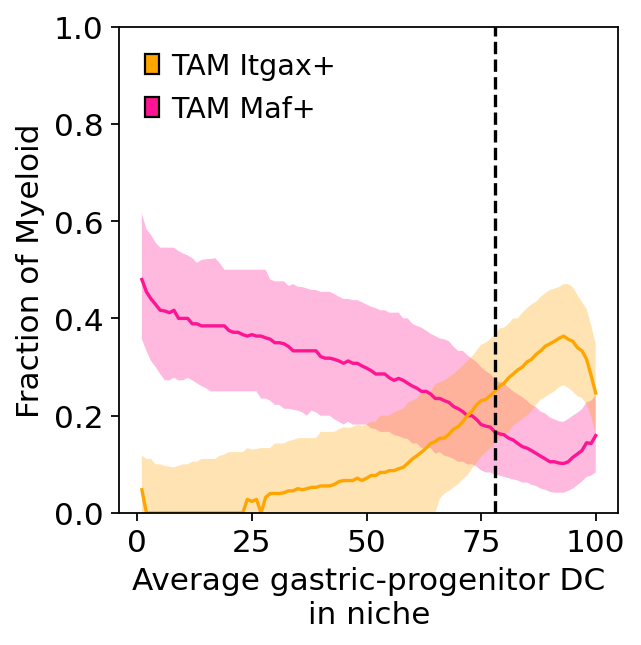

In [ ]:
selected_column = 'count_OBS_cell_type_1_CAT_TAM_Maf'
plt.plot(summarized_median.index, summarized_median[selected_column], 'deeppink')
plt.fill_between(summarized_median.index, summarized_25[selected_column], summarized_75[selected_column], alpha=0.3, color='deeppink', edgecolor='None', label='Confidence Interval')

selected_column = 'count_OBS_cell_type_1_CAT_TAM_Itgax'
plt.plot(summarized_median.index, summarized_median[selected_column], 'orange')
plt.fill_between(summarized_median.index, summarized_25[selected_column], summarized_75[selected_column], alpha=0.3, color='orange', edgecolor='None', label='Confidence Interval')

plt.ylim([0,1])

patches = get_custom_legend_patches(['orange', 'deeppink'], ['TAM Itgax+', 'TAM Maf+'])

plt.legend(handles = patches, frameon=False, loc='upper left')

plt.ylabel('Fraction of Myeloid')
plt.xlabel('Average gastric-progenitor DC\nin niche')

plt.plot([transition_index] * 2, plt.gca().get_ylim(), 'k--')


### Get coarse cell type distributions as a function of DC

In [ ]:
def stacked_bar_chart_from_df(df_fractions, colors):
    # Create the stacked bar chart
    fig, ax = plt.subplots()
    
    # Initialize bottom position for stacking
    bottom = np.zeros(df_fractions.shape[0])
    labels = df_fractions.columns.to_numpy()
    categories = df_fractions.index.to_numpy()
    
    # Iterate through each stack and create bars
    for i, (label, my_color) in enumerate(zip(labels, colors)):
        increment = df_fractions.iloc[:, i].to_numpy()
        ax.bar(categories, increment, bottom=bottom, label=label, color=my_color)
        bottom += increment
    
    # Add labels, title, and legend
    ax.set_xlabel('gastric-progenitor DC')
    ax.set_ylabel('Fraction')
    ax.set_title('Stacked Bar Chart')
    ax.legend(bbox_to_anchor = [0.65, 0, 1, 1], frameon=False)

In [ ]:
np.unique(adata_sub.obs['cell_type_0'])

array(['Adipose', 'Endothelial_Lymphatic', 'Endothelial_Vascular',
       'Epithelial', 'Fibroblast', 'GlialNerves', 'Immune_B',
       'Immune_Myeloid', 'Immune_TNKILC', 'Mesothelial', 'Mixed',
       'MuralCells', 'UnclearEpithelial'], dtype=object)

In [ ]:
selected_columns = [
    'Immune_Myeloid', 'Fibroblast', 'Epithelial', 'Immune_TNKILC', 'Immune_B',
    'Endothelial_Vascular', 'Endothelial_Lymphatic', 'MuralCells',
    'Mesothelial', 'Adipose']
selected_colors = ['gold', 'indigo', 'red', 'royalblue', 'pink', 'limegreen', 'greenyellow', 'paleturquoise', 'lightgray', 'lightgray']


In [ ]:
all_columns = ['count_OBS_cell_type_0_CAT_' + x for x in selected_columns]
df_sub = df.loc[:,all_columns].copy()
df_sub['cell_count'] = df_sub.sum(axis=1)
df_sub['binned_obs'] = df['binned_obs']


In [ ]:
min_valid_epithelial = 10
min_cells_total = 10
valid_niches = ismember(df.index, adata_sub.obs_names)[1]
valid_niches = np.logical_and(valid_niches, df['count_valid_epithelial'] > min_valid_epithelial)
valid_niches = np.logical_and(valid_niches, df_sub['cell_count'] > min_cells_total)

In [ ]:
df_sub = df_sub.loc[valid_niches,:].copy()
df_fractions = df_sub.groupby('binned_obs').agg('sum')

In [ ]:
df_fractions = df_fractions.loc[:,all_columns] / df_fractions['cell_count'][:,None]

/data/lowe/reyesj3/repositories/temp/ipykernel_91636/2448776235.py:1: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  df_fractions = df_fractions.loc[:,all_columns] / df_fractions['cell_count'][:,None]


In [ ]:
df_fractions.columns = [re.sub('count_OBS_cell_type_0_CAT_', '', x) for x in df_fractions.columns]

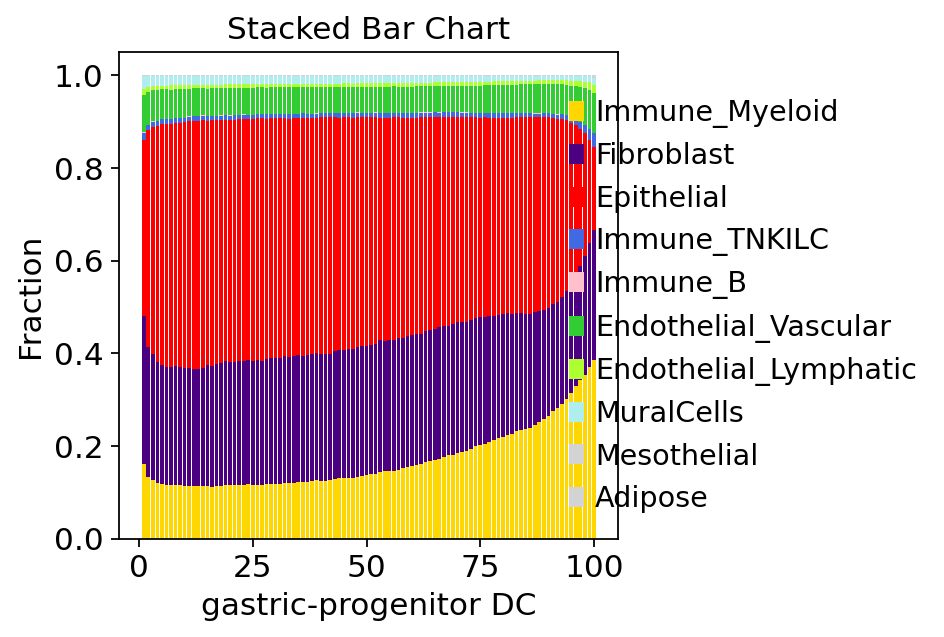

In [ ]:
stacked_bar_chart_from_df(df_fractions.iloc[:-1,:], selected_colors)
